In [1]:
%matplotlib inline
import numpy as np
import os
import pandas as pd
import glob
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import linkage, dendrogram
import japanize_matplotlib

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.cm import get_cmap

import skimage 
from skimage import io
from skimage.color import rgb2gray
from scipy.fftpack import fft2, fftshift
from skimage.draw import circle

In [2]:
path = "../data/"
df = pd.read_csv(path+"imlistD14_38.csv")

batch = df["batchno"].unique()
day = df["day"].unique()

print("batch:",batch)
print("day:",day)
print(batch)
print(day)

#df_test = pd.read_csv(path+"imlist_test.csv")
#df = df[df["day"]==38]
df

batch: ['#8' '#9' '#10' '#11' '#12' '#13']
day: [38 34 31 27 17 20 24 14]
['#8' '#9' '#10' '#11' '#12' '#13']
[38 34 31 27 17 20 24 14]


,Unnamed: 0,batchno,day,dish,fname,Mean82,FLAG
0,0,#8,38,/Day38/#8/#8_0.5A,../data/x4///Day38/#8/#8_0.5A/1_XY01_00107_CH4...,9.0,1
1,1,#8,38,/Day38/#8/#8_0.5A,../data/x4///Day38/#8/#8_0.5A/1_XY01_00117_CH4...,9.0,1
2,2,#8,38,/Day38/#8/#8_0.5A,../data/x4///Day38/#8/#8_0.5A/1_XY01_00121_CH4...,9.0,1
3,3,#8,38,/Day38/#8/#8_0.5A,../data/x4///Day38/#8/#8_0.5A/1_XY01_00092_CH4...,9.0,1
4,4,#8,38,/Day38/#8/#8_0.5A,../data/x4///Day38/#8/#8_0.5A/1_XY01_00120_CH4...,9.0,1
...,...,...,...,...,...,...,...
5707,5707,#13,14,/Day14/#13/#13_0.5-2,../data/x4///Day14/#13/#13_0.5-2/1_XY06_00119_...,18.5,0
5708,5708,#13,14,/Day14/#13/#13_0.5-2,../data/x4///Day14/#13/#13_0.5-2/1_XY06_00134_...,18.5,0
5709,5709,#13,14,/Day14/#13/#13_0.5-2,../data/x4///Day14/#13/#13_0.5-2/1_XY06_00146_...,18.5,0
5710,5710,#13,14,/Day14/#13/#13_0.5-2,../data/x4///Day14/#13/#13_0.5-2/1_XY06_00135_...,18.5,0


In [4]:
df["fname"]

0       ../data/x4///Day38/#8/#8_0.5A/1_XY01_00107_CH4...
1       ../data/x4///Day38/#8/#8_0.5A/1_XY01_00117_CH4...
2       ../data/x4///Day38/#8/#8_0.5A/1_XY01_00121_CH4...
3       ../data/x4///Day38/#8/#8_0.5A/1_XY01_00092_CH4...
4       ../data/x4///Day38/#8/#8_0.5A/1_XY01_00120_CH4...
                              ...                        
5707    ../data/x4///Day14/#13/#13_0.5-2/1_XY06_00119_...
5708    ../data/x4///Day14/#13/#13_0.5-2/1_XY06_00134_...
5709    ../data/x4///Day14/#13/#13_0.5-2/1_XY06_00146_...
5710    ../data/x4///Day14/#13/#13_0.5-2/1_XY06_00135_...
5711    ../data/x4///Day14/#13/#13_0.5-2/1_XY06_00147_...
Name: fname, Length: 5712, dtype: object

(1440, 1920)


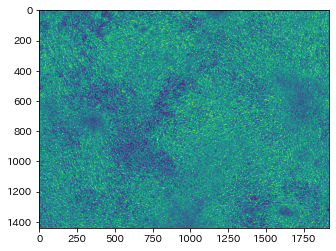

In [5]:
image = io.imread(df["fname"].values[0])
plt.imshow(image)
print(image.shape)

## Feature extraction

In [6]:
def fft(image):
    array = np.abs(fftshift(fft2(image)))
    fft_array = array/np.sum(array)
    return fft_array

def cropimage(imagearr, size):
    cropped_imagearr = imagearr[int(imagearr.shape[0]/2 - size/2):int(imagearr.shape[0]/2 + size/2),int(imagearr.shape[1]/2 - size/2):int(imagearr.shape[1]/2 + size/2) ]
    return cropped_imagearr

def makemask_bound(fft_array,bound):
    mask = np.zeros(fft_array.shape)
    rr, cc = circle(mask.shape[0]/2, mask.shape[1]/2, bound[1], mask.shape)
    _rr, _cc = circle(mask.shape[0]/2, mask.shape[1]/2, bound[0], mask.shape)
    mask[rr, cc] = 1
    mask[_rr, _cc] = 0
    masked_array = np.abs(fft_array)*mask
    return masked_array

def makemask_outer(fft_array,upper):
    mask = np.ones(fft_array.shape)
    rr, cc = circle(mask.shape[0]/2, mask.shape[1]/2, upper, mask.shape)
    mask[rr, cc] = 0
    masked_array = np.abs(fft_array)*mask
    return masked_array

def plot_spectrum(im_fft):
    from matplotlib.colors import LogNorm
    # A logarithmic colormap
    plt.imshow(np.abs(im_fft))
    plt.colorbar()
    
def getscore(list_impath, size):
    scores = []
    for path in list_impath:
        image = io.imread(path)
        image = cropimage(image, 1440)
        _fft = fft(image)
        mask = makemask(_fft,size=size)
        score = np.sum(mask)
        scores.append(score)
    return np.mean(scores)

def get_feature(image,dim):
    array = np.array([])
    _fft = fft(image)
    lenband = round(min(image.shape)/(dim+1),0)
    for i in range(dim):
        bound = [lenband*i, lenband*(i+1)]
        masked_array = makemask_bound(_fft, bound)
        value = np.sum(masked_array)
        array = np.append(array,value)
    #masked_array = makemask_outer(_fft, upper = lenband*(dim-1))
    #value = np.sum(masked_array)
    #array = np.append(array,value)
    return array

In [7]:
get_feature(image, dim =100)

/Users/taku/opt/anaconda3/lib/python3.7/site-packages/skimage/draw/draw.py:40: RuntimeWarning: invalid value encountered in true_divide
  distances = ((r * cos_alpha + c * sin_alpha) / r_rad) ** 2 \
/Users/taku/opt/anaconda3/lib/python3.7/site-packages/skimage/draw/draw.py:41: RuntimeWarning: invalid value encountered in true_divide
  + ((r * sin_alpha - c * cos_alpha) / c_rad) ** 2


array([6.57341873e-03, 5.12657786e-03, 6.90760765e-03, 8.81330027e-03,
       1.11652652e-02, 1.34918523e-02, 1.52649666e-02, 1.69446355e-02,
       1.82272773e-02, 1.94428538e-02, 2.05946785e-02, 2.16198115e-02,
       2.21618812e-02, 2.27027916e-02, 2.30719224e-02, 2.33002520e-02,
       2.35565963e-02, 2.36547311e-02, 2.35807804e-02, 2.35912662e-02,
       2.31347887e-02, 2.31225417e-02, 2.29586726e-02, 2.25261026e-02,
       2.21633359e-02, 2.17805487e-02, 2.11603045e-02, 2.06626952e-02,
       2.01234671e-02, 1.96071347e-02, 1.90050544e-02, 1.84037876e-02,
       1.79195698e-02, 1.72336207e-02, 1.66178766e-02, 1.61981505e-02,
       1.57318056e-02, 1.51865473e-02, 1.46055936e-02, 1.42989374e-02,
       1.38646449e-02, 1.33336209e-02, 1.30225678e-02, 1.26372595e-02,
       1.23041008e-02, 1.21145954e-02, 1.17479386e-02, 1.15104343e-02,
       1.12325770e-02, 1.09382132e-02, 1.07685160e-02, 1.02569191e-02,
       9.16409414e-03, 8.56145904e-03, 7.97447803e-03, 7.59364432e-03,
      

## Create Table

In [8]:
dim = 100
X = np.array([])
for index, row in df.iterrows():
    print(index)
    impath = row["fname"]
    image = io.imread(impath)
    vec = get_feature(image, dim = dim)
    X = np.append(X,vec)
    
X = X.reshape(int(len(X)/dim),dim)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

/Users/taku/opt/anaconda3/lib/python3.7/site-packages/skimage/external/tifffile/tifffile.py:2618: RuntimeWarning: py_decodelzw encountered unexpected end of stream
  strip = decompress(strip)


1102
1103
1104
1105
1106
1107
1108
1109
1110
1111
1112
1113
1114
1115
1116
1117
1118
1119
1120
1121
1122
1123
1124
1125
1126
1127
1128
1129
1130
1131
1132
1133
1134
1135
1136
1137
1138
1139
1140
1141
1142
1143
1144
1145
1146
1147
1148
1149
1150
1151
1152
1153
1154
1155
1156
1157
1158
1159
1160
1161
1162
1163
1164
1165
1166
1167
1168
1169
1170
1171
1172
1173
1174
1175
1176
1177
1178
1179
1180
1181
1182
1183
1184
1185
1186
1187
1188
1189
1190
1191
1192
1193
1194
1195
1196
1197
1198
1199
1200
1201
1202
1203
1204
1205
1206
1207
1208
1209
1210
1211
1212
1213
1214
1215
1216
1217
1218
1219
1220
1221
1222
1223
1224
1225
1226
1227
1228
1229
1230
1231
1232
1233
1234
1235
1236
1237
1238
1239
1240
1241
1242
1243
1244
1245
1246
1247
1248
1249
1250
1251
1252
1253
1254
1255
1256
1257
1258
1259
1260
1261
1262
1263
1264
1265
1266
1267
1268
1269
1270
1271
1272
1273
1274
1275
1276
1277
1278
1279
1280
1281
1282
1283
1284
1285
1286
1287
1288
1289
1290
1291
1292
1293
1294
1295
1296
1297
1298
1299
1300
1301


2741
2742
2743
2744
2745
2746
2747
2748
2749
2750
2751
2752
2753
2754
2755
2756
2757
2758
2759
2760
2761
2762
2763
2764
2765
2766
2767
2768
2769
2770
2771
2772
2773
2774
2775
2776
2777
2778
2779
2780
2781
2782
2783
2784
2785
2786
2787
2788
2789
2790
2791
2792
2793
2794
2795
2796
2797
2798
2799
2800
2801
2802
2803
2804
2805
2806
2807
2808
2809
2810
2811
2812
2813
2814
2815
2816
2817
2818
2819
2820
2821
2822
2823
2824
2825
2826
2827
2828
2829
2830
2831
2832
2833
2834
2835
2836
2837
2838
2839
2840
2841
2842
2843
2844
2845
2846
2847
2848
2849
2850
2851
2852
2853
2854
2855
2856
2857
2858
2859
2860
2861
2862
2863
2864
2865
2866
2867
2868
2869
2870
2871
2872
2873
2874
2875
2876
2877
2878
2879
2880
2881
2882
2883
2884
2885
2886
2887
2888
2889
2890
2891
2892
2893
2894
2895
2896
2897
2898
2899
2900
2901
2902
2903
2904
2905
2906
2907
2908
2909
2910
2911
2912
2913
2914
2915
2916
2917
2918
2919
2920
2921
2922
2923
2924
2925
2926
2927
2928
2929
2930
2931
2932
2933
2934
2935
2936
2937
2938
2939
2940


4380
4381
4382
4383
4384
4385
4386
4387
4388
4389
4390
4391
4392
4393
4394
4395
4396
4397
4398
4399
4400
4401
4402
4403
4404
4405
4406
4407
4408
4409
4410
4411
4412
4413
4414
4415
4416
4417
4418
4419
4420
4421
4422
4423
4424
4425
4426
4427
4428
4429
4430
4431
4432
4433
4434
4435
4436
4437
4438
4439
4440
4441
4442
4443
4444
4445
4446
4447
4448
4449
4450
4451
4452
4453
4454
4455
4456
4457
4458
4459
4460
4461
4462
4463
4464
4465
4466
4467
4468
4469
4470
4471
4472
4473
4474
4475
4476
4477
4478
4479
4480
4481
4482
4483
4484
4485
4486
4487
4488
4489
4490
4491
4492
4493
4494
4495
4496
4497
4498
4499
4500
4501
4502
4503
4504
4505
4506
4507
4508
4509
4510
4511
4512
4513
4514
4515
4516
4517
4518
4519
4520
4521
4522
4523
4524
4525
4526
4527
4528
4529
4530
4531
4532
4533
4534
4535
4536
4537
4538
4539
4540
4541
4542
4543
4544
4545
4546
4547
4548
4549
4550
4551
4552
4553
4554
4555
4556
4557
4558
4559
4560
4561
4562
4563
4564
4565
4566
4567
4568
4569
4570
4571
4572
4573
4574
4575
4576
4577
4578
4579


In [9]:
df["batchno"]

0        #8
1        #8
2        #8
3        #8
4        #8
       ... 
5707    #13
5708    #13
5709    #13
5710    #13
5711    #13
Name: batchno, Length: 5712, dtype: object

## dataframeを作成する

In [10]:
df_feature = pd.DataFrame(X)
df_feature["batchno"]=df["batchno"].values
df_feature["day"]=df["day"].values
df_feature["dish"]=df["dish"].values
df_feature["score"]=df["Mean82"].values
df_feature["FLAG"]=df["FLAG"].values


#df_feature.to_csv("../data/fftfeature/featureall.csv")
df_feature.to_csv("../data/featureD14_D38.csv")

In [11]:
df_feature38 = df_feature[df_feature["day"]==38]
df_feature34 = df_feature[df_feature["day"]==34]
df_feature31 = df_feature[df_feature["day"]==31]
df_feature27 = df_feature[df_feature["day"]==27]
df_feature24 = df_feature[df_feature["day"]==24]
df_feature20 = df_feature[df_feature["day"]==20]
df_feature17 = df_feature[df_feature["day"]==17]
df_feature14 = df_feature[df_feature["day"]==14]


df_feature38.to_csv("../data/fftfeatureD14_D38/feature38.csv")
df_feature34.to_csv("../data/fftfeatureD14_D38/feature34.csv")
df_feature31.to_csv("../data/fftfeatureD14_D38/feature31.csv")
df_feature27.to_csv("../data/fftfeatureD14_D38/feature27.csv")
df_feature24.to_csv("../data/fftfeatureD14_D38/feature24.csv")
df_feature20.to_csv("../data/fftfeatureD14_D38/feature20.csv")
df_feature17.to_csv("../data/fftfeatureD14_D38/feature17.csv")
df_feature14.to_csv("../data/fftfeatureD14_D38/feature14.csv")

## PCA

In [12]:
decomp = PCA()
X_decomp = decomp.fit_transform(X[:,:])
df_decomp = pd.DataFrame(X_decomp)
df_decomp["batchno"]=df["batchno"]
df_decomp["day"]=df["day"]
df_decomp["score"]=df["Mean82"]
df_decomp["FLAG"]=df["FLAG"]

df_decomp.to_csv("../data/decomp_d14d38.csv")

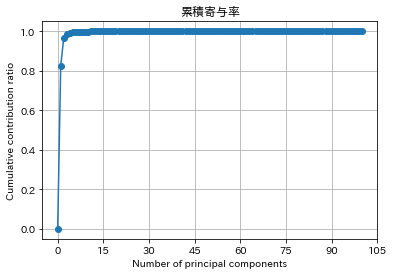

In [13]:
plt.gca().get_xaxis().set_major_locator(ticker.MaxNLocator(integer=True))
plt.plot([0] + list( np.cumsum(decomp.explained_variance_ratio_)), "-o")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative contribution ratio")
plt.title("累積寄与率")
plt.grid()
plt.show()

In [14]:
df_decomp

,0,1,2,3,4,5,6,7,8,9,...,94,95,96,97,98,99,batchno,day,score,FLAG
0,-0.026048,-0.002159,-0.001018,-0.001492,0.000632,0.000649,0.000741,0.000135,0.000174,-0.000299,...,-1.657371e-18,-1.933681e-18,-1.279240e-18,-1.717968e-18,-1.276705e-18,-1.645361e-18,#8,38,9.0,1
1,-0.025520,0.001036,-0.003238,-0.000249,0.000279,-0.000051,-0.000051,0.000572,-0.000694,-0.000011,...,-1.390681e-19,1.546460e-19,-6.876329e-19,-6.407479e-19,-2.955215e-19,-3.868628e-20,#8,38,9.0,1
2,-0.023701,-0.001151,-0.000439,-0.001856,-0.000019,0.000921,0.000804,0.000401,-0.000285,-0.000007,...,4.145548e-19,2.953521e-19,-3.593688e-19,-4.306296e-19,-1.204586e-19,3.657800e-19,#8,38,9.0,1
3,-0.025462,-0.001819,-0.001501,-0.001418,0.000367,0.000479,0.000410,0.000242,0.000545,-0.000247,...,-4.074720e-19,-1.233663e-18,-1.577939e-19,-1.283103e-18,-7.289162e-19,-8.506774e-19,#8,38,9.0,1
4,-0.029966,0.000517,-0.002399,-0.001179,0.000167,0.000357,0.000474,0.000101,0.000283,-0.000154,...,5.241971e-19,-4.380430e-19,6.957244e-19,3.803457e-19,3.277377e-20,6.510841e-19,#8,38,9.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5707,-0.011878,0.015433,0.005880,-0.000501,-0.000471,0.000786,0.000085,-0.000467,0.000275,-0.000002,...,-1.201650e-19,3.599581e-19,4.014914e-20,-5.271115e-20,-1.630276e-19,-8.676059e-20,#13,14,18.5,0
5708,-0.011655,0.015182,0.005068,-0.000317,-0.000549,0.000255,-0.000090,-0.000514,0.000095,-0.000306,...,-4.827799e-20,3.050234e-19,-1.343957e-19,-1.208708e-19,8.186388e-20,-2.778929e-20,#13,14,18.5,0
5709,-0.010722,0.015506,0.004969,0.000121,-0.000631,0.000318,-0.000117,-0.000541,-0.000067,-0.000023,...,8.058061e-20,1.437995e-19,2.327427e-19,-8.255115e-20,8.801467e-20,1.031363e-19,#13,14,18.5,0
5710,-0.011729,0.015189,0.004864,0.000270,-0.000650,0.000476,-0.000040,-0.000853,-0.000172,0.000094,...,2.374573e-19,2.039271e-19,7.275304e-20,7.207354e-20,-3.490128e-20,-1.278634e-19,#13,14,18.5,0


In [15]:
batch = df_decomp["batchno"].unique()
day = df_decomp["day"].unique()
flag = [1, 0]

print("batch:",batch)
print("day:",day)

batch: ['#8' '#9' '#10' '#11' '#12' '#13']
day: [38 34 31 27 17 20 24 14]


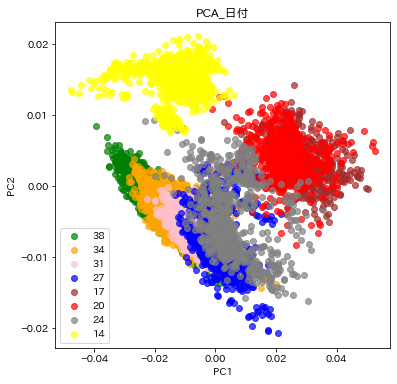

In [16]:
colorlist = ["green","orange","pink","blue","brown","red","grey","yellow"]

cmap = get_cmap("tab10")
plt.figure(figsize=(6,6))
for i,name in enumerate(day):
    _df = df_decomp[df_decomp["day"]==name]
    plt.scatter(_df[0], _df[1], color=colorlist[i],label=name, alpha=0.7)
plt.title("PCA_日付")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

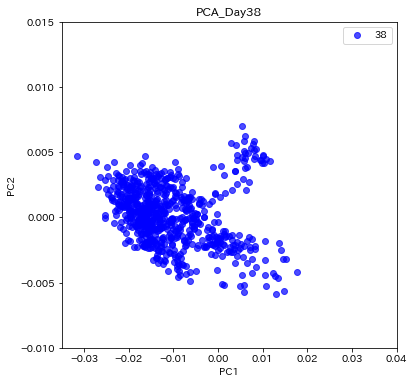

In [98]:
name = 38
plt.figure(figsize=(6,6))
_df = df_decomp[df_decomp["day"]==name]
plt.scatter(_df[0], _df[1], color=colorlist[i],label=name, alpha=0.7)

plt.title("PCA_Day"+str(name))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.xlim(-0.035,0.04)
plt.ylim(-0.01,0.015)
plt.legend()
plt.show()

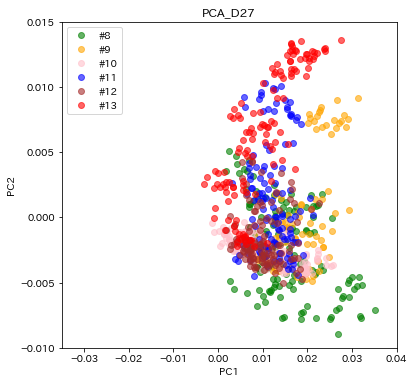

In [105]:
colorlist = ["green","orange","pink","blue","brown","red","grey","yellow"]
d =27

cmap = get_cmap("tab10")
plt.figure(figsize=(6,6))
for i,name in enumerate(batch):
    _df = df_decomp[df_decomp["batchno"]==name]
    _df = _df[_df["day"]==d]
    plt.scatter(_df[0], _df[1], color=colorlist[i],label=name, alpha=0.6)
plt.title("PCA_D"+str(d))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.xlim(-0.035,0.04)
plt.ylim(-0.01,0.015)
plt.legend()
plt.show()

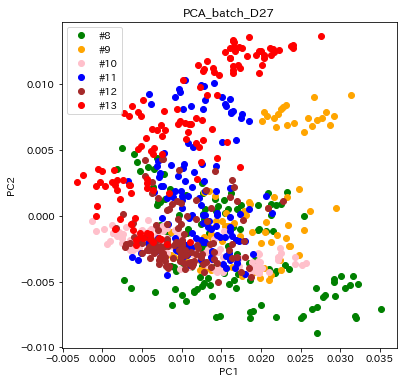

In [83]:
colorlist = ["green","orange","pink","blue","brown","red","grey","yellow"]

cmap = get_cmap("tab10")
plt.figure(figsize=(6,6))
for i,name in enumerate(batch):
    _df = df_decomp[df_decomp["batchno"]==name]
    _df = _df[_df["day"]==27]
    plt.scatter(_df[0], _df[1], color=colorlist[i],label=name)
plt.title("PCA_batch_D27")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

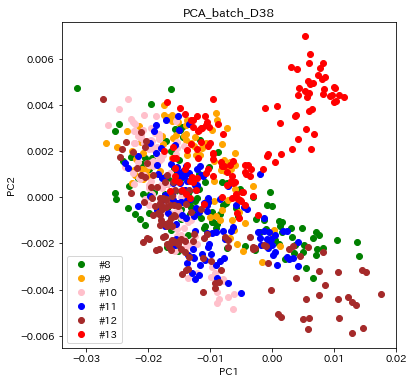

In [85]:
colorlist = ["green","orange","pink","blue","brown","red","grey","yellow"]

cmap = get_cmap("tab10")
plt.figure(figsize=(6,6))
for i,name in enumerate(batch):
    _df = df_decomp[df_decomp["batchno"]==name]
    _df = _df[_df["day"]==38]
    plt.scatter(_df[0], _df[1], color=colorlist[i],label=name)
plt.title("PCA_batch_D38")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

## 10以上か以下か

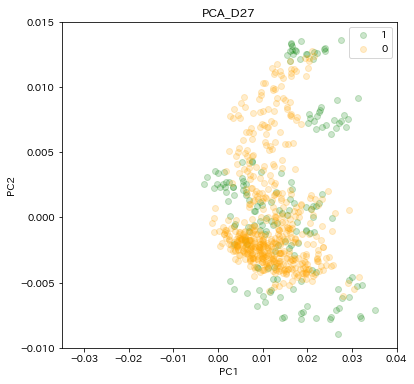

In [127]:
cmap = get_cmap("tab10")
d =27

plt.figure(figsize=(6,6))
for i,name in enumerate(flag):
    _df = df_decomp[df_decomp["FLAG"]==name]
    _df = _df[_df["day"]==d]
    plt.scatter(_df[0], _df[1], color=colorlist[i],label=name,alpha=0.2)
plt.title("PCA_D"+str(d))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.xlim(-0.035,0.04)
plt.ylim(-0.01,0.015)
plt.legend()
plt.show()

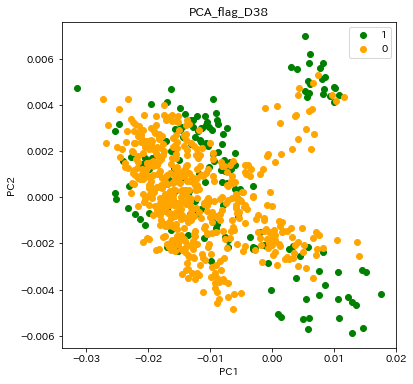

In [89]:
cmap = get_cmap("tab10")
plt.figure(figsize=(6,6))
for i,name in enumerate(flag):
    _df = df_decomp[df_decomp["FLAG"]==name]
    _df = _df[_df["day"]==38]
    plt.scatter(_df[0], _df[1], color=colorlist[i],label=name)
plt.title("PCA_flag_D38")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

## t-SNE

In [73]:
decomp = TSNE(n_components=2)
X_tsne = decomp.fit_transform(X)
df_tsne = pd.DataFrame(X_tsne)
df_tsne["batchno"]=df["batchno"]
df_tsne["day"]=df["day"]
df_tsne["score"]=df["Mean82"]
df_tsne["FLAG"]=df["FLAG"]

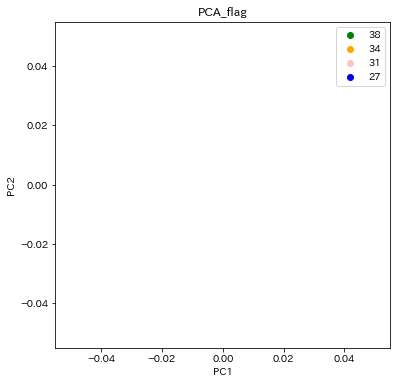

In [74]:
cmap = get_cmap("tab10")
plt.figure(figsize=(6,6))
for i,name in enumerate(day):
    _df = df_tsne[df_tsne["batchno"]==name]
    _df = _df[_df["day"]==38]
    plt.scatter(_df[0], _df[1], color=colorlist[i],label=name)
plt.title("t-SNE_flag")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

In [9]:
dim = 9
X = np.array([])
for index, row in df_test.iterrows():
    print(index)
    impath = row["fname"]
    image = io.imread(impath)
    vec = get_feature(image, dim = dim)
    X = np.append(X,vec)
    
X = X.reshape(int(len(X)/dim),dim)

0


/Users/taku/opt/anaconda3/envs/py36/lib/python3.6/site-packages/ipykernel_launcher.py:12: FutureWarning: circle is deprecated in favor of disk.circle will be removed in version 0.19
  if sys.path[0] == '':
/Users/taku/opt/anaconda3/envs/py36/lib/python3.6/site-packages/ipykernel_launcher.py:13: FutureWarning: circle is deprecated in favor of disk.circle will be removed in version 0.19
  del sys.path[0]


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [10]:
Y = np.array([df_test["FLAG"]]).T
Z = np.hstack([X,Y])
print(X.shape)
print(Y.shape)
print(Z.shape)

(346, 9)
(346, 1)
(346, 10)


In [11]:
cols = ["1","2","3","4","5","6","7","8","9","FLAG"]
datatable =  pd.DataFrame(Z,columns=cols)

In [12]:
datatable.to_csv(path+"naivefeature_test.csv")

## Logistic Regression

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)

lr = LogisticRegression()
lr.fit(X_train, Y_train)

/Users/taku/opt/anaconda3/envs/py36/lib/python3.6/site-packages/sklearn/utils/validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


LogisticRegression()

## Test model

In [44]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

Y_pred = lr.predict(X_test)
print('confusion matrix = \n', confusion_matrix(y_true=Y_test, y_pred=Y_pred))
print('accuracy = ', accuracy_score(y_true=Y_test, y_pred=Y_pred))
print('precision = ', precision_score(y_true=Y_test, y_pred=Y_pred))
print('recall = ', recall_score(y_true=Y_test, y_pred=Y_pred))
print('f1 score = ', f1_score(y_true=Y_test, y_pred=Y_pred))

confusion matrix = 
 [[121   0]
 [ 72   0]]
accuracy =  0.6269430051813472
precision =  0.0
recall =  0.0
f1 score =  0.0


/Users/taku/opt/anaconda3/envs/py36/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


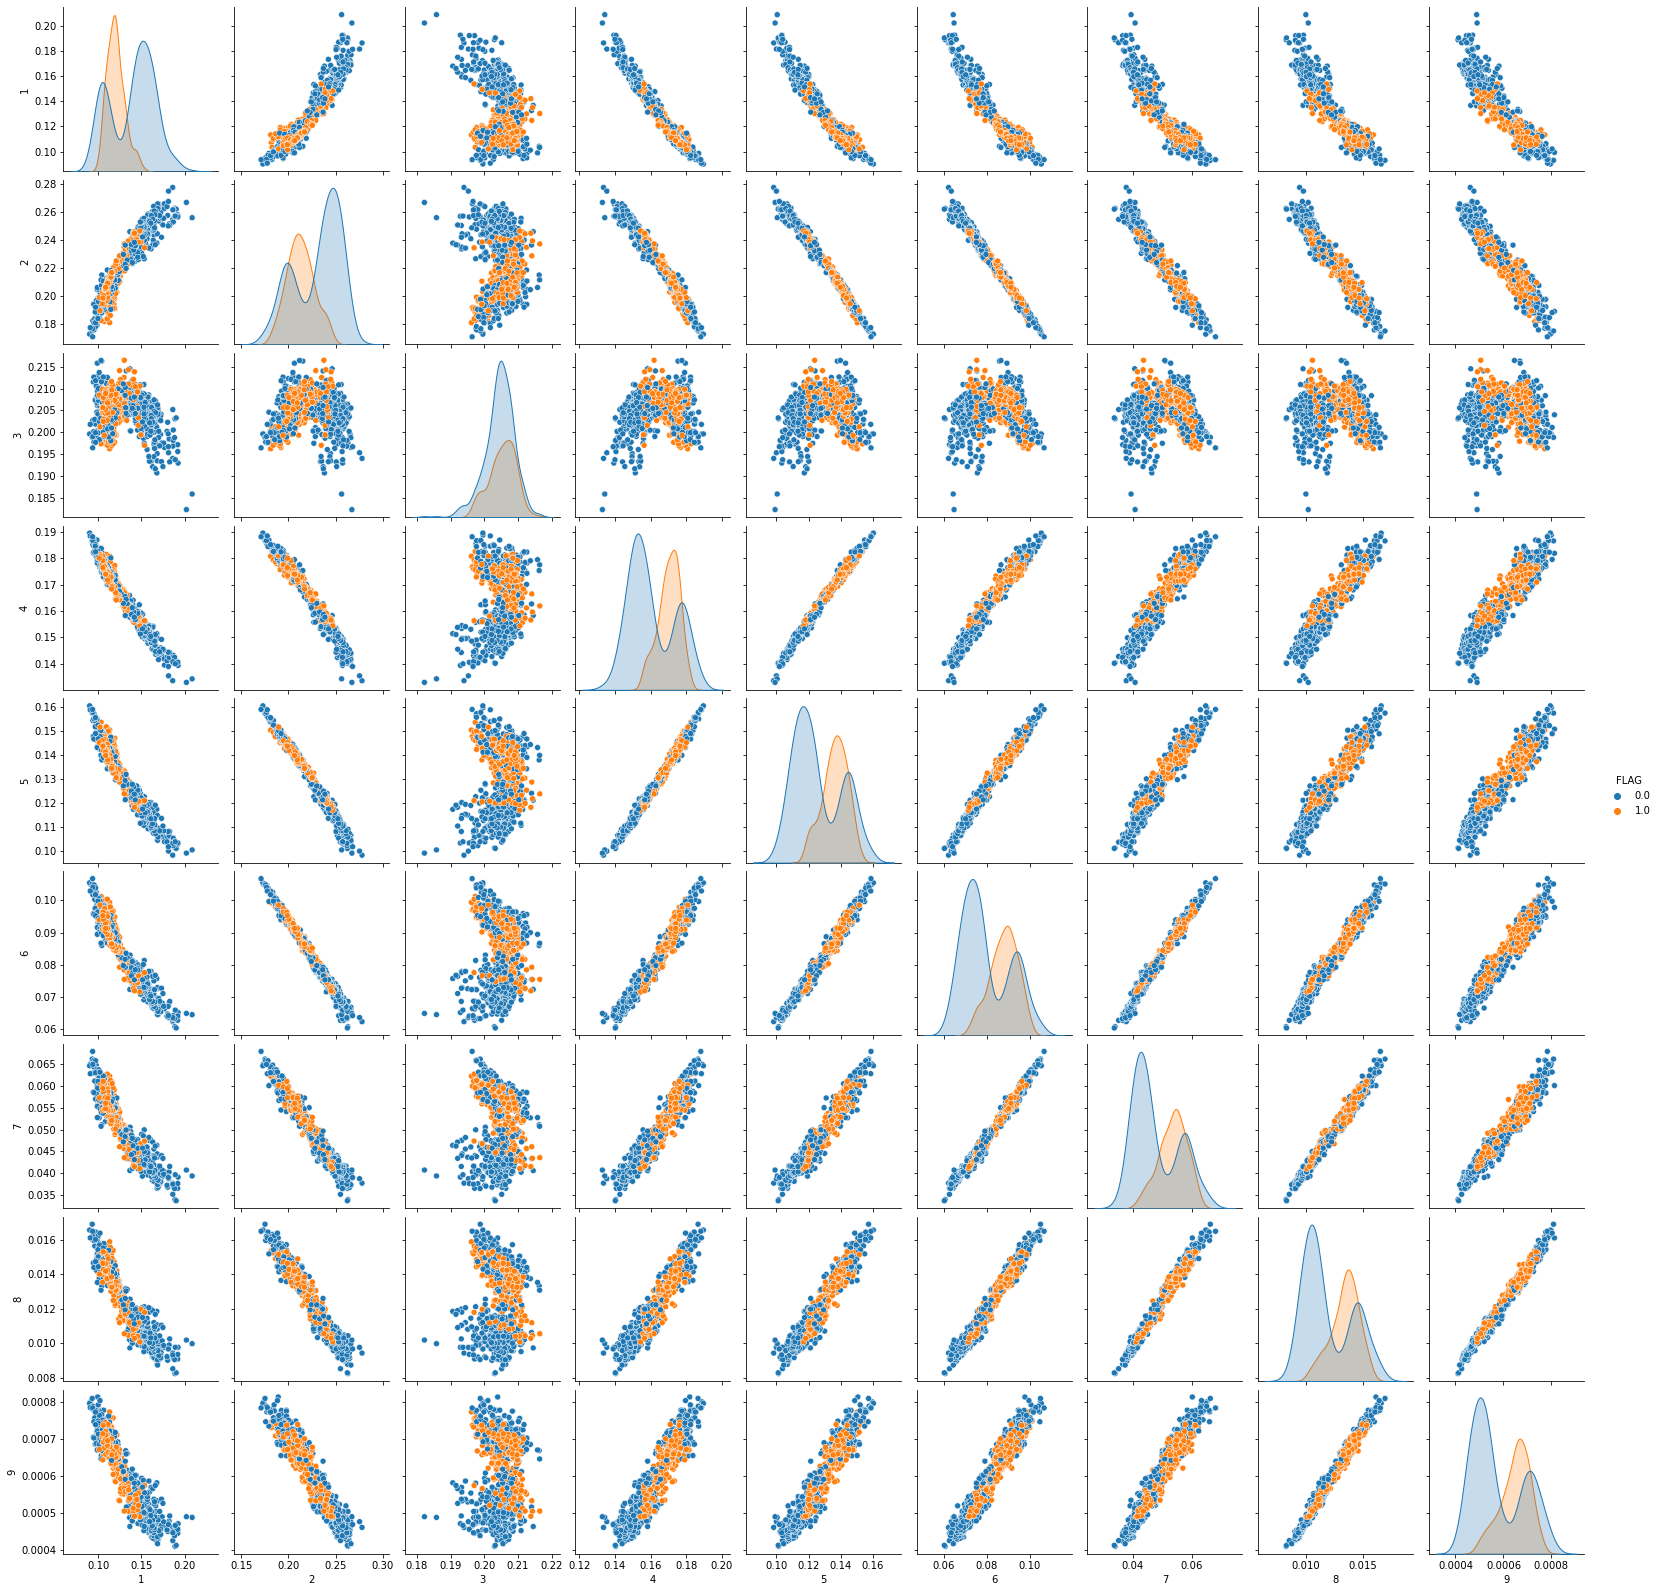

In [49]:
import seaborn as sns

sns.pairplot(datatable,hue="FLAG")
plt.show()

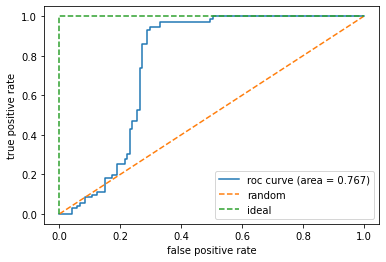

In [50]:
from sklearn.metrics import roc_curve, auc

Y_score = lr.predict_proba(X_test)[:, 1] # 検証データがクラス1に属する確率
fpr, tpr, thresholds = roc_curve(y_true=Y_test, y_score=Y_score)

plt.plot(fpr, tpr, label='roc curve (area = %0.3f)' % auc(fpr, tpr))
plt.plot([0, 1], [0, 1], linestyle='--', label='random')
plt.plot([0, 0, 1], [0, 1, 1], linestyle='--', label='ideal')
plt.legend()
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.show()